# Demand Forecasting: Deep Learning Implementation (Production Ready)
This notebook implements a Bidirectional LSTM model with strict chronological splitting, entity-aware sequence generation, reproducibility seeds, and per-entity evaluation.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### 1. Data Loading & Preprocessing

In [2]:
# Load Data
df = pd.read_csv('demand_forecasting_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# One-Hot Encode
df_encoded = pd.get_dummies(df, columns=['store', 'product'], prefix=['store', 'prod'])
df_encoded['store'] = df['store']      # Keep for grouping
df_encoded['product'] = df['product']  # Keep for grouping

# Strict Chronological Split
dates = df_encoded['date'].sort_values().unique()
train_cutoff = dates[int(len(dates) * 0.70)]
val_cutoff = dates[int(len(dates) * 0.85)]

train_df = df_encoded[df_encoded['date'] <= train_cutoff]
val_df = df_encoded[(df_encoded['date'] > train_cutoff) & (df_encoded['date'] <= val_cutoff)]
test_df = df_encoded[df_encoded['date'] > val_cutoff]

# Setup Features & Scaling
exclude_cols = ['date', 'store', 'product', 'demand']
features = ['demand'] + [col for col in df_encoded.columns if col not in exclude_cols]
target_index = 0
lookback_days = 30

n_stores = df['store'].nunique()
n_products = df['product'].nunique()
print(f"Dataset contains {n_stores} stores and {n_products} products.")
print(f"Feature vector size per timestep after OHE: {len(features)}")

scaler = MinMaxScaler()
scaler.fit(train_df[features])

Dataset contains 3 stores and 5 products.
Feature vector size per timestep after OHE: 17


,feature_range,"(0, ...)"
,copy,True
,clip,False


### 2. Entity-Aware Sequence Generation

In [3]:
def process_groups_into_sequences(df_subset, scaler, features, lookback, target_index=0, split_name=None):
    X, y = [], []
    skipped = 0
    
    for (store, product), group in df_subset.groupby(['store', 'product']):
        group = group.sort_values('date')
        if len(group) <= lookback:
            skipped += 1
            continue
            
        scaled_data = scaler.transform(group[features])
        for i in range(len(scaled_data) - lookback):
            X.append(scaled_data[i:(i + lookback)])
            y.append(scaled_data[i + lookback, target_index])
            
    if split_name:
        print(f"{split_name} Split: Created {len(X)} sequences. Skipped {skipped} groups (insufficient history).")
    return np.array(X), np.array(y)

X_train, y_train = process_groups_into_sequences(train_df, scaler, features, lookback_days, target_index, "Train")
X_val, y_val = process_groups_into_sequences(val_df, scaler, features, lookback_days, target_index, "Val")
X_test, y_test = process_groups_into_sequences(test_df, scaler, features, lookback_days, target_index, "Test")

Train Split: Created 7215 sequences. Skipped 0 groups (insufficient history).
Val Split: Created 1200 sequences. Skipped 0 groups (insufficient history).
Test Split: Created 1185 sequences. Skipped 0 groups (insufficient history).


### 3. Build & Train Model

In [4]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
checkpoint = ModelCheckpoint('best_bi_lstm_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler, checkpoint],
    shuffle=False,
    verbose=1
)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 0.0127 - mae: 0.0765 - val_loss: 0.0044 - val_mae: 0.0463 - learning_rate: 0.0010
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0049 - mae: 0.0501 - val_loss: 0.0145 - val_mae: 0.0705 - learning_rate: 0.0010
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0075 - mae: 0.0592 - val_loss: 0.0109 - val_mae: 0.0634 - learning_rate: 0.0010
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0048 - mae: 0.0471 - val_loss: 0.0033 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0030 - mae: 0.0390 - val_loss: 0.0021 - val_mae: 0.0327 - learning_rate: 0.0010
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0025 - mae: 0.0355 - val_loss: 0.0024 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0026 - mae: 0.0356 - val_loss: 0.0022 - val_mae: 0.0362 - learning_rate: 0.00

### 4. Training History Visualization

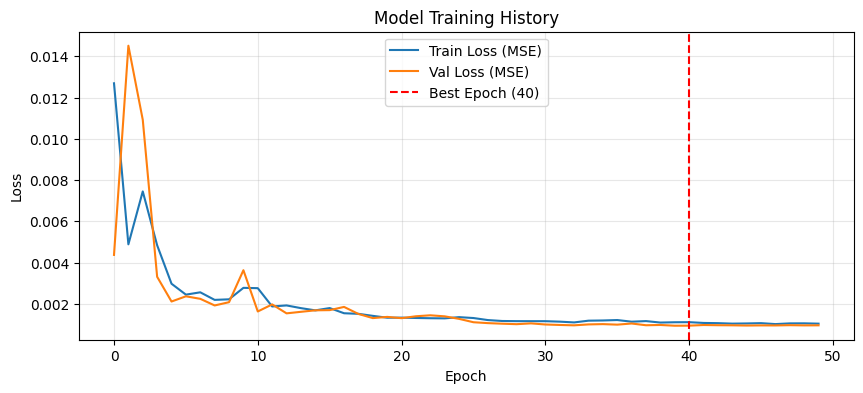

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
if early_stopping.stopped_epoch > 0:
    best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1
    plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Evaluation & Dynamic Entity Visualization

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

--- Overall Test Set Performance ---
MAE:  9.62
RMSE: 15.38
R2:   0.9611

--- Per-Entity Test Set Performance (MAE) ---
Store_A - Clothing: MAE = 8.94


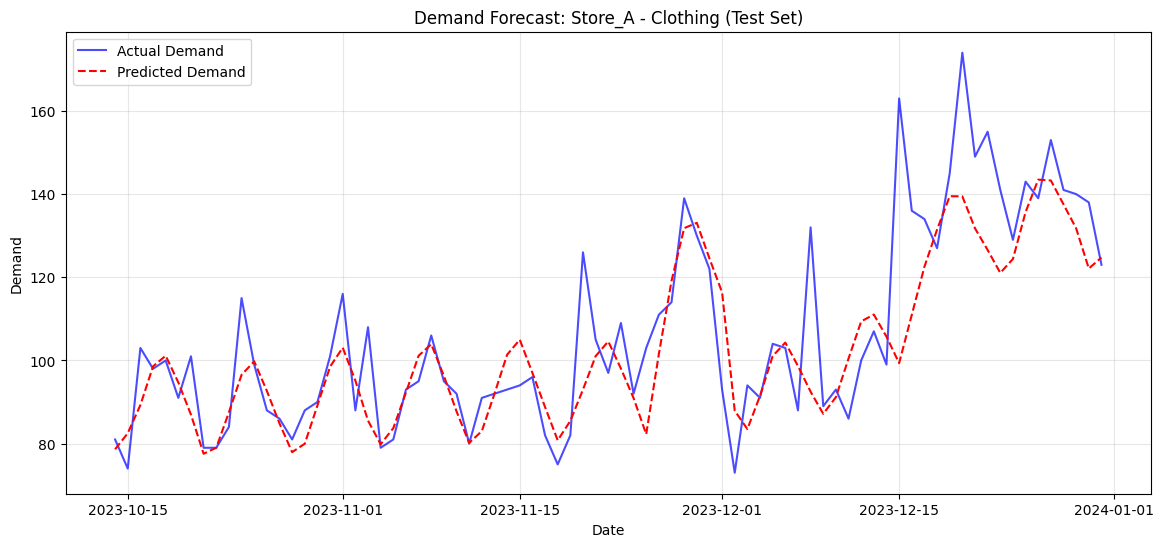

Store_A - Electronics: MAE = 6.71
Store_A - Furniture: MAE = 4.82
Store_A - Groceries: MAE = 20.27
Store_A - Toys: MAE = 7.28
Store_B - Clothing: MAE = 11.17
Store_B - Electronics: MAE = 6.55
Store_B - Furniture: MAE = 2.62
Store_B - Groceries: MAE = 20.87
Store_B - Toys: MAE = 6.94
Store_C - Clothing: MAE = 11.28
Store_C - Electronics: MAE = 5.36
Store_C - Furniture: MAE = 3.12
Store_C - Groceries: MAE = 20.09
Store_C - Toys: MAE = 8.34


In [6]:
def inverse_transform_demand(scaled_y, scaler_obj, feature_count):
    dummy = np.zeros((len(scaled_y), feature_count))
    dummy[:, 0] = scaled_y.flatten()
    return scaler_obj.inverse_transform(dummy)[:, 0]

y_pred_scaled = model.predict(X_test)
y_pred = inverse_transform_demand(y_pred_scaled, scaler, len(features))
y_test_actual = inverse_transform_demand(y_test, scaler, len(features))

print("\n--- Overall Test Set Performance ---")
print(f"MAE:  {mean_absolute_error(y_test_actual, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred)):.2f}")
print(f"R2:   {r2_score(y_test_actual, y_pred):.4f}")

print("\n--- Per-Entity Test Set Performance (MAE) ---")
plotted = False
for (sample_store, sample_product), sample_df in test_df.groupby(['store', 'product']):
    X_g, y_g_true = process_groups_into_sequences(sample_df, scaler, features, lookback_days, target_index)
    if len(X_g) == 0:
        continue

    y_g_pred_scaled = model.predict(X_g, verbose=0)
    y_g_pred = inverse_transform_demand(y_g_pred_scaled, scaler, len(features))
    y_g_actual = inverse_transform_demand(y_g_true, scaler, len(features))
    mae = mean_absolute_error(y_g_actual, y_g_pred)
    print(f"{sample_store} - {sample_product}: MAE = {mae:.2f}")

    if not plotted:
        plt.figure(figsize=(14, 6))
        plt.plot(sample_df['date'].iloc[lookback_days:], y_g_actual, label='Actual Demand', color='blue', alpha=0.7)
        plt.plot(sample_df['date'].iloc[lookback_days:], y_g_pred, label='Predicted Demand', color='red', linestyle='--')
        plt.title(f'Demand Forecast: {sample_store} - {sample_product} (Test Set)')
        plt.xlabel('Date')
        plt.ylabel('Demand')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        plotted = True

if not plotted:
    print("Could not find any single store/product combo in the test set with enough sequential days to plot.")